<a href="https://colab.research.google.com/github/engMohamedAbdAlslam/DRP_segmentation/blob/copilot%2Fdevelop-preprocessing-pipeline/notebooks/04_dr_grading_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — DR Grading Model (EfficientNet-B4)
**Dataset:** APTOS 2019 (preprocessed `.npz` from NB01)
**Goal:** Train EfficientNet-B4 to classify DR severity into 5 grades (0–4).
**Metrics:** Accuracy, Quadratic Weighted Kappa (QWK), F1-score, AUC-ROC
> Run on **Google Colab** with T4 GPU. Drive must be mounted with NB01 output at `DRP_processed/aptos2019/`.

## 1. Colab Repo Setup

In [1]:
import os
from pathlib import Path

repo_path = Path('/content/DRP_segmentation')
if not repo_path.exists():
    !git clone https://github.com/engMohamedAbdAlslam/DRP_segmentation.git /content/DRP_segmentation
%cd /content/DRP_segmentation
!git checkout copilot/develop-preprocessing-pipeline
!git pull origin copilot/develop-preprocessing-pipeline
print('Repo ready at', Path.cwd())

Cloning into '/content/DRP_segmentation'...
remote: Enumerating objects: 283, done.
remote: Counting objects: 100% (283/283), done.
remote: Compressing objects: 100% (210/210), done.
remote: Total 283 (delta 149), reused 162 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (283/283), 4.52 MiB | 10.77 MiB/s, done.
Resolving deltas: 100% (149/149), done.
/content/DRP_segmentation
Branch 'copilot/develop-preprocessing-pipeline' set up to track remote branch 'copilot/develop-preprocessing-pipeline' from 'origin'.
Switched to a new branch 'copilot/develop-preprocessing-pipeline'
From https://github.com/engMohamedAbdAlslam/DRP_segmentation
 * branch            copilot/develop-preprocessing-pipeline -> FETCH_HEAD
Already up to date.
Repo ready at /content/DRP_segmentation


In [2]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

## 2. Install Dependencies

In [3]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', '-q', 'install',
                'timm', 'scikit-learn', 'tqdm', 'matplotlib', 'numpy', 'torch', 'torchvision'],
               check=True)
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

PyTorch: 2.11.0+cu128
CUDA available: True
Device: Tesla T4


## 3. Imports & Config

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import (cohen_kappa_score, f1_score,
                             classification_report, confusion_matrix,
                             roc_auc_score)
from pathlib import Path
from tqdm import tqdm
import json, shutil

# ── Config ──
DRIVE_BASE    = Path('/content/drive/MyDrive/DRP_processed/aptos2019')
MODEL_NAME    = 'efficientnet_b4'
NUM_CLASSES   = 5
BATCH_SIZE = 8          # down from 16/32
IMAGE_SIZE = 380        # down from 512 if you're using 512
NUM_EPOCHS    = 20
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 5       # early stopping
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED          = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {DEVICE} | Model: {MODEL_NAME} | Epochs: {NUM_EPOCHS}')

Device: cuda | Model: efficientnet_b4 | Epochs: 20


## 4. Mount Drive & Verify Data

In [5]:
from google.colab import drive
drive.mount('/content/drive')

for split in ['train', 'val', 'test']:
    p = DRIVE_BASE / split
    count = len(list(p.rglob('*.npz'))) if p.exists() else 0
    status = '✔' if count > 0 else '❌'
    print(f'{status} {split}: {count} files')

Mounted at /content/drive
✔ train: 2051 files
✔ val: 439 files
✔ test: 440 files


## 5. Dataset Class

In [6]:
from google.colab import userdata
import os, json

token_raw = userdata.get('KAGGLE_TOKEN')

if token_raw and token_raw.strip().startswith('{'):

    t = json.loads(token_raw)
    os.environ['KAGGLE_USERNAME'] = t['username']
    os.environ['KAGGLE_KEY']      = t['key']
else:

    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY']      = token_raw

print(f"✅ Kaggle ready — user: {os.environ['KAGGLE_USERNAME']}")

✅ Kaggle ready — user: zainalabidinshbani


In [7]:
class APTOSDataset(Dataset):
    """Loads preprocessed .npz files from NB01.
    Each file contains: image (H,W,3) float32 imagenet-normalized, metadata JSON.
    Label is extracted from filename: *_grade{N}.npz
    """
    def __init__(self, split_dir: Path, augment: bool = False):
        self.files = sorted(split_dir.rglob('*.npz'))
        self.augment = augment
        self.aug_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ]) if augment else None
        assert len(self.files) > 0, f'No .npz files found in {split_dir}'

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data  = np.load(self.files[idx], allow_pickle=True)
        image = data['image'].astype(np.float32)  # (H, W, 3)
        # Extract grade from filename: stem ends with _grade{N}
        stem  = self.files[idx].stem              # e.g. '0a4e1a29_grade2'
        label = int(stem.split('_grade')[-1])
        # HWC -> CHW for PyTorch
        image = torch.from_numpy(image).permute(2, 0, 1)  # (3, H, W)
        if self.augment and self.aug_transform:
            image = self.aug_transform(image)
        return image, label

# Build datasets
train_ds = APTOSDataset(DRIVE_BASE / 'train', augment=True)
val_ds   = APTOSDataset(DRIVE_BASE / 'val',   augment=False)
test_ds  = APTOSDataset(DRIVE_BASE / 'test',  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
# Class distribution
from collections import Counter
labels = [int(f.stem.split('_grade')[-1]) for f in train_ds.files]
print('Train class dist:', dict(sorted(Counter(labels).items())))

Train: 2051 | Val: 439 | Test: 440
Train class dist: {0: 1004, 1: 210, 2: 565, 3: 108, 4: 164}


## 6. Model — EfficientNet-B4

In [8]:
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# Class weights for imbalanced dataset
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced',
                                      classes=np.arange(NUM_CLASSES),
                                      y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print('Class weights:', class_weights.cpu().numpy().round(3))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Model: {MODEL_NAME} | Params: {total_params:.1f}M')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Class weights: [0.409 1.953 0.726 3.798 2.501]
Model: efficientnet_b4 | Params: 17.6M


## 7. Training Loop

In [9]:
# ── Imports for AMP ──
import gc
import torch
from torch.amp import GradScaler, autocast

torch.cuda.empty_cache()
gc.collect()

scaler = GradScaler('cuda')


# ── Training loop helper ──
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with (torch.enable_grad() if training else torch.no_grad()):
        for images, labels_batch in tqdm(loader, leave=False):
            images       = images.to(device, non_blocking=True)
            labels_batch = labels_batch.to(device, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)
                with autocast('cuda'):
                    outputs = model(images)
                    loss    = criterion(outputs, labels_batch)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                with autocast('cuda'):
                    outputs = model(images)
                    loss    = criterion(outputs, labels_batch)

            preds       = outputs.argmax(dim=1)
            total_loss += loss.item() * images.size(0)
            correct    += (preds == labels_batch).sum().item()
            total      += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    avg_loss = total_loss / total
    acc      = correct / total
    qwk      = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return avg_loss, acc, qwk, all_preds, all_labels


# ── Training ──
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_qwk':  [], 'val_qwk':  []
}
best_qwk    = -1.0
patience_ct = 0
best_path   = Path('/content/best_efficientnet_b4.pth')

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_qwk, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, vl_qwk, _, _ = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)
    history['train_qwk'].append(tr_qwk);   history['val_qwk'].append(vl_qwk)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'Acc {tr_acc:.3f}/{vl_acc:.3f} | '
          f'QWK {tr_qwk:.3f}/{vl_qwk:.3f}')

    # Save best model based on validation QWK
    if vl_qwk > best_qwk:
        best_qwk    = vl_qwk
        patience_ct = 0
        torch.save(model.state_dict(), best_path)
        print(f'  ✓ New best QWK: {best_qwk:.4f} — model saved')
    else:
        patience_ct += 1
        if patience_ct >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nBest Val QWK: {best_qwk:.4f}')

Epoch 01/20 | Loss 1.3445/1.2015 | Acc 0.570/0.661 | QWK 0.566/0.680
  ✓ New best QWK: 0.6803 — model saved


Epoch 02/20 | Loss 0.9743/0.9604 | Acc 0.715/0.731 | QWK 0.808/0.835
  ✓ New best QWK: 0.8348 — model saved


Epoch 03/20 | Loss 0.8198/0.9018 | Acc 0.760/0.756 | QWK 0.825/0.864
  ✓ New best QWK: 0.8636 — model saved


Epoch 04/20 | Loss 0.7221/0.9067 | Acc 0.798/0.722 | QWK 0.862/0.867
  ✓ New best QWK: 0.8667 — model saved


Epoch 05/20 | Loss 0.6238/0.8638 | Acc 0.823/0.809 | QWK 0.882/0.880
  ✓ New best QWK: 0.8801 — model saved


...

Epoch 13/20 | Loss 0.2296/1.0494 | Acc 0.934/0.800 | QWK 0.957/0.896


Epoch 14/20 | Loss 0.2255/1.0611 | Acc 0.936/0.802 | QWK 0.960/0.904


Epoch 15/20 | Loss 0.1800/1.1072 | Acc 0.951/0.797 | QWK 0.971/0.887


Epoch 16/20 | Loss 0.1905/1.0956 | Acc 0.951/0.806 | QWK 0.974/0.895


Epoch 17/20 | Loss 0.1837/1.1632 | Acc 0.949/0.806 | QWK 0.970/0.903
Early stopping at epoch 17

Best Val QWK: 0.9071


## 8. Training Curves

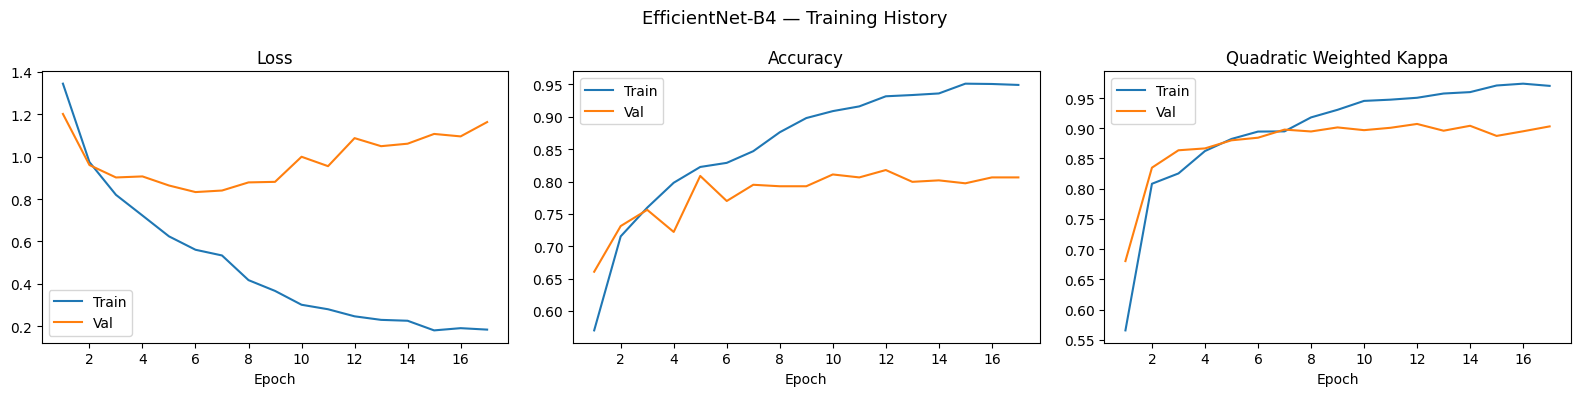

In [10]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_ran, history['train_loss'], label='Train'); axes[0].plot(epochs_ran, history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_ran, history['train_acc'], label='Train'); axes[1].plot(epochs_ran, history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_ran, history['train_qwk'], label='Train'); axes[2].plot(epochs_ran, history['val_qwk'], label='Val')
axes[2].set_title('Quadratic Weighted Kappa'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle('EfficientNet-B4 — Training History', fontsize=13)
plt.tight_layout(); plt.show()

## 9. Evaluation on Test Set

Test Accuracy : 0.8364
Test QWK      : 0.9044
Test F1 (macro): 0.7259

Classification Report:
               precision    recall  f1-score   support

        No DR       0.99      0.95      0.97       215
         Mild       0.58      0.64      0.61        45
     Moderate       0.79      0.79      0.79       122
       Severe       0.59      0.57      0.58        23
Proliferative       0.66      0.71      0.68        35

     accuracy                           0.84       440
    macro avg       0.72      0.73      0.73       440
 weighted avg       0.84      0.84      0.84       440



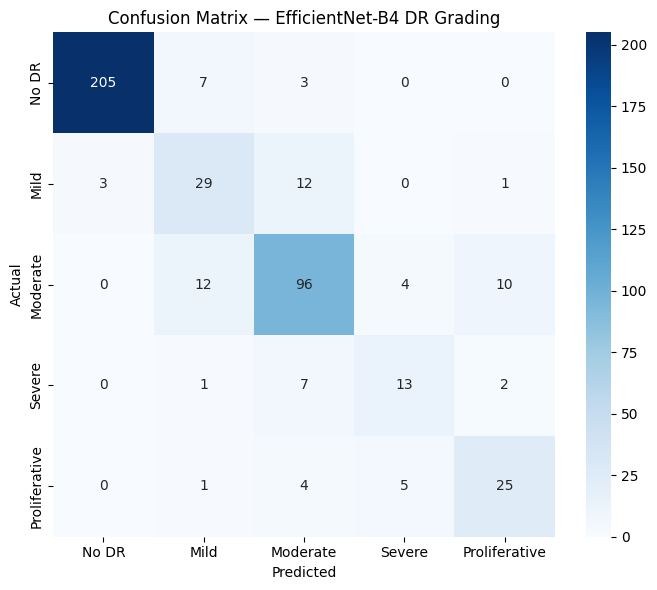

In [11]:
# Load best model
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
_, test_acc, test_qwk, test_preds, test_labels = run_epoch(model, test_loader, criterion)

DR_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test QWK      : {test_qwk:.4f}')
print(f'Test F1 (macro): {f1_score(test_labels, test_preds, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=DR_NAMES))

# Confusion Matrix
import seaborn as sns
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DR_NAMES, yticklabels=DR_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — EfficientNet-B4 DR Grading')
plt.tight_layout(); plt.show()

## 10. Save Model to Google Drive

In [12]:
models_dir = Path('/content/drive/MyDrive/DRP_models')
models_dir.mkdir(parents=True, exist_ok=True)

dest = models_dir / 'efficientnet_b4_dr_grading.pth'
shutil.copy(best_path, dest)

# Save training metadata
meta = {
    'model': MODEL_NAME,
    'num_classes': NUM_CLASSES,
    'best_val_qwk': round(best_qwk, 4),
    'test_acc': round(test_acc, 4),
    'test_qwk': round(test_qwk, 4),
    'epochs_trained': len(history['train_loss']),
    'input_size': '512x512',
    'normalization': 'imagenet',
    'dataset': 'APTOS 2019'
}
with open(models_dir / 'efficientnet_b4_dr_grading_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Model saved → {dest}')
print(f'Metadata: {meta}')

Model saved → /content/drive/MyDrive/DRP_models/efficientnet_b4_dr_grading.pth
Metadata: {'model': 'efficientnet_b4', 'num_classes': 5, 'best_val_qwk': np.float64(0.9071), 'test_acc': 0.8364, 'test_qwk': np.float64(0.9044), 'epochs_trained': 17, 'input_size': '512x512', 'normalization': 'imagenet', 'dataset': 'APTOS 2019'}


## Next Steps
- **NB07:** Apply Grad-CAM on this model to generate explainability heatmaps
- **NB08:** Load this model in the Gradio clinical interface
- Model path: `DRP_models/efficientnet_b4_dr_grading.pth`